**ASSIGNMENT 3**      
Name : Priya Rajkumar Jadhav     
Class : AI-B    
Batch : A      
Roll no : 23107098    




Title :- Develop a sentiment analysis model to analyze customer reviews of products or services.

In [ ]:
import pandas as pd

df = pd.read_csv("redmi6.csv", encoding="latin1")
df

,Review Title,Customer name,Rating,Date,Category,Comments,Useful
0,Another Midrange killer Smartphone by Xiaomi,Rishikumar Thakur,4.0 out of 5 stars,on 1 October 2018,Display,Another Midrange killer Smartphone by Xiaomi\n...,
1,vry small size mobile,Raza ji,3.0 out of 5 stars,on 15 September 2018,Others,All ok but vry small size mobile,7 people found this helpful
2,Full display not working in all application.,Vaibhav Patel,3.0 out of 5 stars,on 18 September 2018,Others,Quite good,7 people found this helpful
3,Value for Money,Amazon Customer,5.0 out of 5 stars,on 28 September 2018,Display,Redmi has always have been the the king of bud...,2 people found this helpful
4,Not worth for the money,Sudhakaran Wadakkancheri,2.0 out of 5 stars,on 18 September 2018,Others,worst product from MI. I am a hardcore fan of ...,6 people found this helpful
...,...,...,...,...,...,...,...
275,"Cemera quality,face unlock most important in t...",Rahul,5.0 out of 5 stars,on 19 September 2018,Others,"I like This Phone, Awesome look and design.\nI...",NaN
276,Mi is best phone,Sunil Soni,4.0 out of 5 stars,on 18 September 2018,Others,Product is avasome but invoice is note include...,NaN
277,Its a OK Phone,D.C.Padhi,3.0 out of 5 stars,on 15 September 2018,Battery,"Redmi Note4, Note5, now 6pro..It seems the old...",NaN
278,Redmi,Mahesh,5.0 out of 5 stars,on 21 September 2018,Others,I love mi,NaN


In [ ]:

df['rating_num'] = df['Rating'].str[0].astype(int)
df

,Review Title,Customer name,Rating,Date,Category,Comments,Useful,rating_num
0,Another Midrange killer Smartphone by Xiaomi,Rishikumar Thakur,4.0 out of 5 stars,on 1 October 2018,Display,Another Midrange killer Smartphone by Xiaomi\n...,,4
1,vry small size mobile,Raza ji,3.0 out of 5 stars,on 15 September 2018,Others,All ok but vry small size mobile,7 people found this helpful,3
2,Full display not working in all application.,Vaibhav Patel,3.0 out of 5 stars,on 18 September 2018,Others,Quite good,7 people found this helpful,3
3,Value for Money,Amazon Customer,5.0 out of 5 stars,on 28 September 2018,Display,Redmi has always have been the the king of bud...,2 people found this helpful,5
4,Not worth for the money,Sudhakaran Wadakkancheri,2.0 out of 5 stars,on 18 September 2018,Others,worst product from MI. I am a hardcore fan of ...,6 people found this helpful,2
...,...,...,...,...,...,...,...,...
275,"Cemera quality,face unlock most important in t...",Rahul,5.0 out of 5 stars,on 19 September 2018,Others,"I like This Phone, Awesome look and design.\nI...",NaN,5
276,Mi is best phone,Sunil Soni,4.0 out of 5 stars,on 18 September 2018,Others,Product is avasome but invoice is note include...,NaN,4
277,Its a OK Phone,D.C.Padhi,3.0 out of 5 stars,on 15 September 2018,Battery,"Redmi Note4, Note5, now 6pro..It seems the old...",NaN,3
278,Redmi,Mahesh,5.0 out of 5 stars,on 21 September 2018,Others,I love mi,NaN,5


In [ ]:
def rating_to_sentiment(r):
    if r >= 4:
        return "Positive"
    else:
        return "Negative"



In [ ]:
df['Sentiment'] = df['rating_num'].apply(rating_to_sentiment)

df.head()

,Review Title,Customer name,Rating,Date,Category,Comments,Useful,rating_num,Sentiment
0,Another Midrange killer Smartphone by Xiaomi,Rishikumar Thakur,4.0 out of 5 stars,on 1 October 2018,Display,Another Midrange killer Smartphone by Xiaomi\n...,,4,Positive
1,vry small size mobile,Raza ji,3.0 out of 5 stars,on 15 September 2018,Others,All ok but vry small size mobile,7 people found this helpful,3,Negative
2,Full display not working in all application.,Vaibhav Patel,3.0 out of 5 stars,on 18 September 2018,Others,Quite good,7 people found this helpful,3,Negative
3,Value for Money,Amazon Customer,5.0 out of 5 stars,on 28 September 2018,Display,Redmi has always have been the the king of bud...,2 people found this helpful,5,Positive
4,Not worth for the money,Sudhakaran Wadakkancheri,2.0 out of 5 stars,on 18 September 2018,Others,worst product from MI. I am a hardcore fan of ...,6 people found this helpful,2,Negative


In [ ]:

X = df['Comments'].astype(str)
y = df['Sentiment']

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.feature_extraction.text import TfidfVectorizer

custom_stopwords = list(ENGLISH_STOP_WORDS - {'not', 'no', 'never'})

tfidf = TfidfVectorizer(
    stop_words=custom_stopwords,
    ngram_range=(1,2)
)



X_tfidf = tfidf.fit_transform(X)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42
)


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    class_weight='balanced',
)

model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced')

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.8571428571428571
              precision    recall  f1-score   support

    Negative       0.61      0.92      0.73        12
    Positive       0.97      0.84      0.90        44

    accuracy                           0.86        56
   macro avg       0.79      0.88      0.82        56
weighted avg       0.90      0.86      0.87        56



In [ ]:
from sklearn.naive_bayes import MultinomialNB

In [ ]:
model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.8928571428571429
              precision    recall  f1-score   support

    Negative       1.00      0.50      0.67        12
    Positive       0.88      1.00      0.94        44

    accuracy                           0.89        56
   macro avg       0.94      0.75      0.80        56
weighted avg       0.91      0.89      0.88        56



In [ ]:
from sklearn.svm import LinearSVC

In [ ]:
model = LinearSVC()

model.fit(X_train, y_train)

LinearSVC()

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.8571428571428571
              precision    recall  f1-score   support

    Negative       0.70      0.58      0.64        12
    Positive       0.89      0.93      0.91        44

    accuracy                           0.86        56
   macro avg       0.80      0.76      0.77        56
weighted avg       0.85      0.86      0.85        56



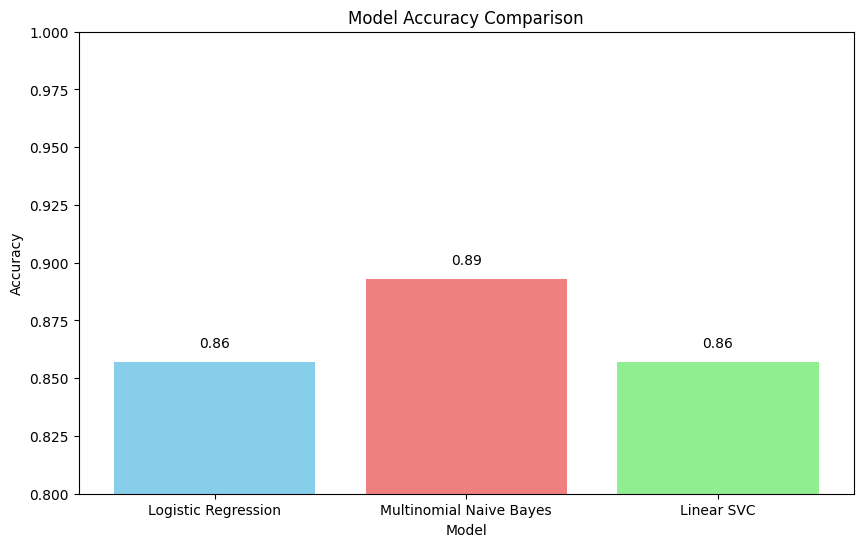

In [ ]:


accuracy_lr = 0.8571428571428571
accuracy_mnb = 0.8928571428571429
accuracy_svc = 0.8571428571428571

model_names = ['Logistic Regression', 'Multinomial Naive Bayes', 'Linear SVC']
accuracies = [accuracy_lr, accuracy_mnb, accuracy_svc]

accuracy_df = pd.DataFrame({
    'Model': model_names,
    'Accuracy': accuracies
})

plt.figure(figsize=(10, 6))
plt.bar(accuracy_df['Model'], accuracy_df['Accuracy'], color=['skyblue', 'lightcoral', 'lightgreen'])
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.ylim(0.8, 1.0)

for i, accuracy in enumerate(accuracies):
    plt.text(i, accuracy + 0.005, f'{accuracy:.2f}', ha='center', va='bottom')

plt.show()